In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll_time, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [2]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [3]:
config_path = '../configs/config_aids.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [4]:
# task_id = config['dataset_kwargs']['task_id']
# task_id
config['landmark']

True

In [5]:
task_id = 'aids_ds'

In [6]:
model = DeepLambdaSA(config, seed=42)

In [7]:
train_gen, _ = model.get_train_test()

In [8]:
def get_masks_initstate_ibs(h, n):
    aux = jnp.zeros(h).at[0].set(1)
    return jnp.tile(aux, n)

In [55]:
%%time

num_exps = 7
sizes = [.2]
size = sizes[0]
tgt_lrs = [.0001, .001, .005, .01, .05]

bs_0 = np.zeros((num_exps, len(tgt_lrs)))
bs_1 = np.zeros((num_exps, len(tgt_lrs)))

ci_0 = np.zeros((num_exps, len(tgt_lrs)))
ci_1 = np.zeros((num_exps, len(tgt_lrs)))

for fold in range(num_exps):
    for i, tgt_lr in enumerate(tgt_lrs):
        config['target_lr'] = tgt_lr
        
        print(".", end="")
        
        # Landmarking.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:,0])
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:,0])
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.....
.....
.....
.....
.....
.....
.....
CPU times: user 58.8 s, sys: 603 ms, total: 59.4 s
Wall time: 58.7 s


Text(0.5, 0, 'Test size proportion')

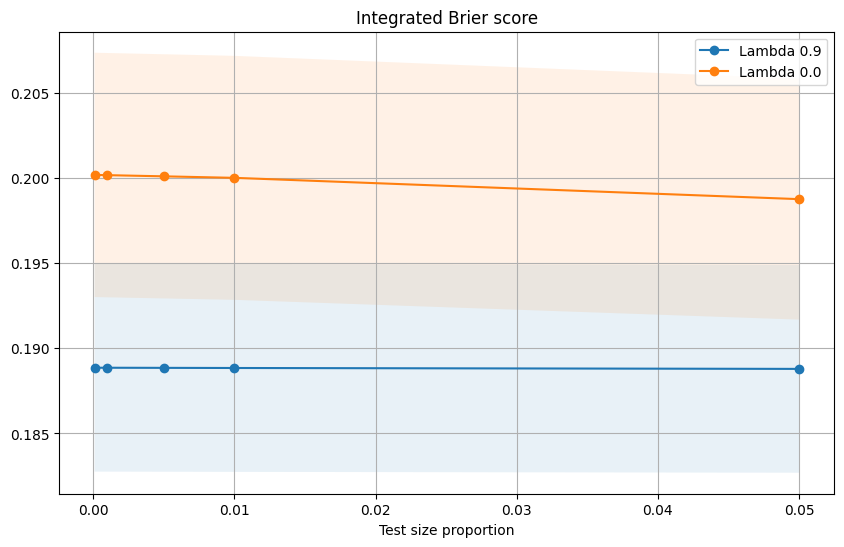

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((bs_1, "Lambda 0.9"), (bs_0, "Lambda 0.0")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(tgt_lrs, mean, marker="o", label=label)
    ax.fill_between(tgt_lrs, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Test size proportion")

Text(0.5, 0, 'Test size proportion')

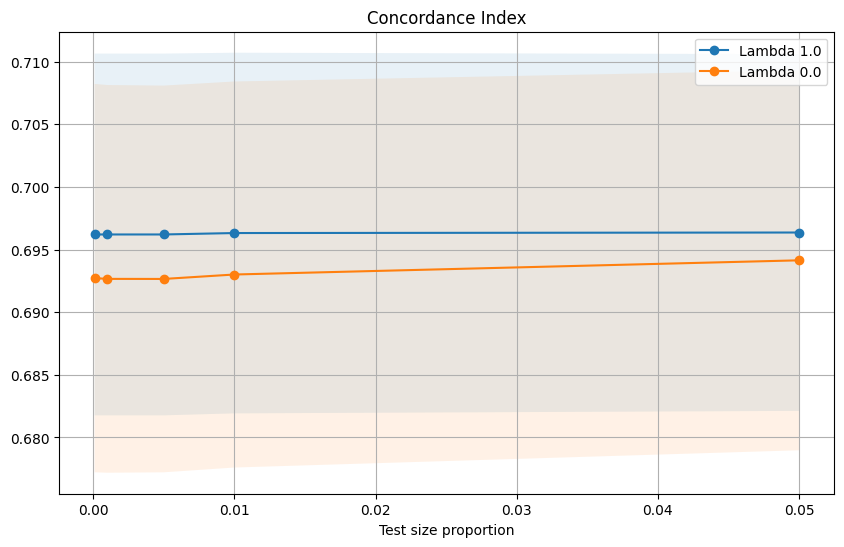

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((ci_1, "Lambda 1.0"), (ci_0, "Lambda 0.0")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(tgt_lrs, mean, marker="o", label=label)
    ax.fill_between(tgt_lrs, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance Index")
ax.set_xlabel("Test size proportion")

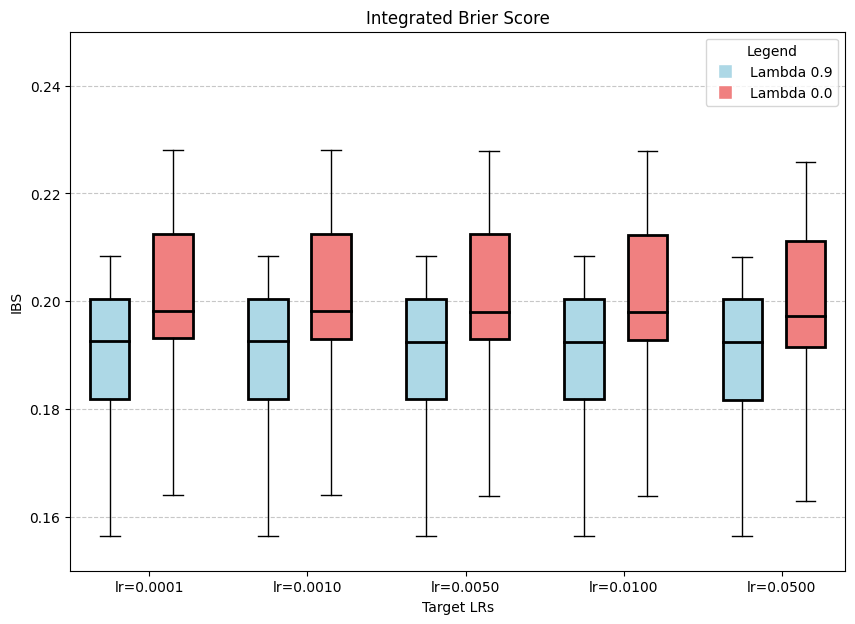

In [109]:
X = bs_1

Y = bs_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(labels))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(labels))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('IBS')
plt.title('Integrated Brier Score')

# Set y-axis limits
plt.ylim(0.15, .25)

plt.show()


In [102]:
positions

array([1, 3, 5, 7, 9])

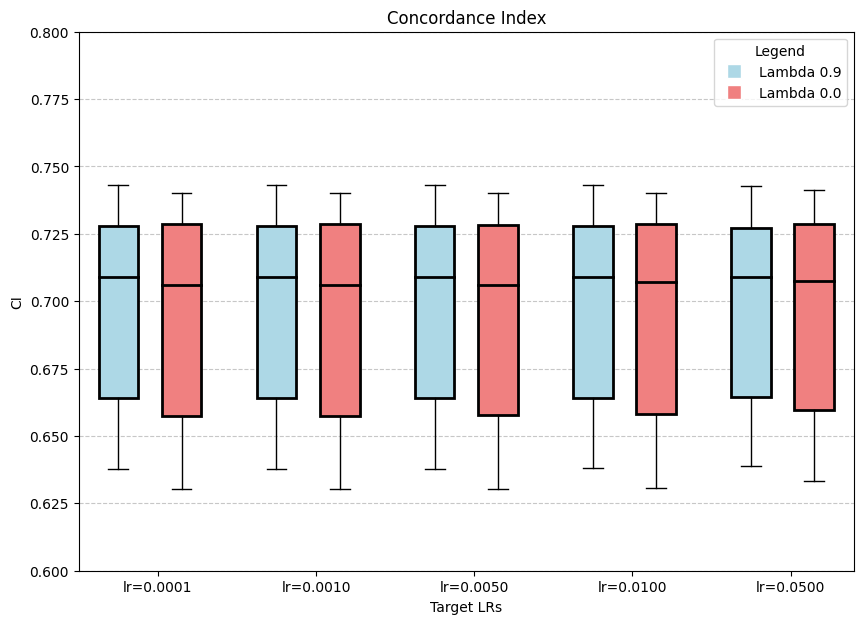

In [112]:
X = ci_1
Y = ci_0

# Create a list of positions for the boxplots
positions = np.arange(1, X.shape[1]*2, step=2)

# Set box colors
boxprops_X = dict(facecolor='lightblue', edgecolor='black', linewidth=2)
boxprops_Y = dict(facecolor='lightcoral', edgecolor='black', linewidth=2)

# Set mean line properties
medianprops = dict(color='black', linewidth=2)

# Set figure size
plt.figure(figsize=(10, 7))

# Plotting boxplots for X
plt.boxplot(X, positions=positions, labels=['' for i in range(len(labels))], boxprops=boxprops_X, medianprops=medianprops, patch_artist=True)

# Plotting boxplots for Y
plt.boxplot(Y, positions=positions + 0.8, labels=['' for i in range(len(labels))], boxprops=boxprops_Y, medianprops=medianprops, patch_artist=True)

# Create legend
legend_X = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightblue', markersize=10, label='Lambda 0.9')
legend_Y = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lightcoral', markersize=10, label='Lambda 0.0')

plt.legend(handles=[legend_X, legend_Y], title='Legend')

# Customize the grid to have only horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set x-axis labels within boxplots
labels = [f'lr={lr:.4f}' for lr in tgt_lrs]
plt.xticks(positions+.5, labels, ha='center')


plt.xlabel('Target LRs')
plt.ylabel('CI')
plt.title('Concordance Index')

# Set y-axis limits
plt.ylim(0.6, .8)

plt.show()


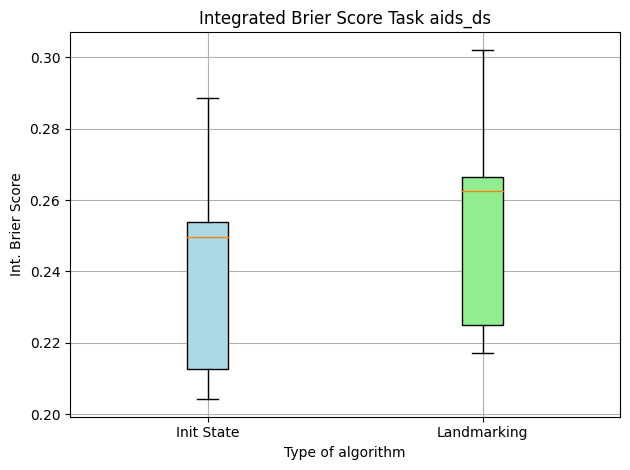

In [10]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res2_is.reshape(-1)
y = res2_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/Int_brier_score_task_{}.pdf".format(task_id), format="pdf")

plt.show()

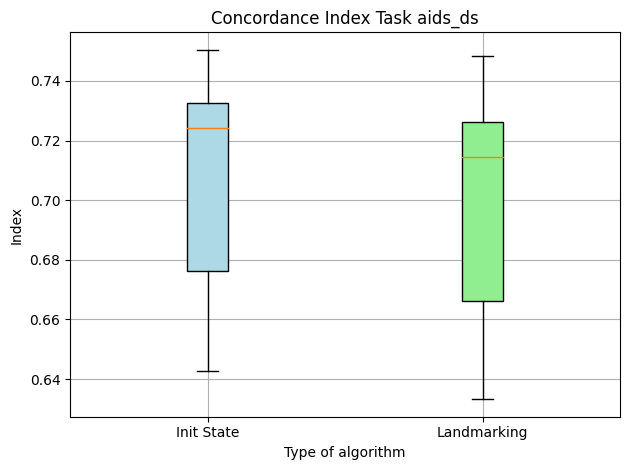

In [11]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res3_is.reshape(-1)
y = res3_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Index")
ax.set_title("Concordance Index Task {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("../../Figures/conc_idx_task_{}.pdf".format(task_id), format="pdf")

plt.show()


In [44]:
config['target_lr'] = 0.5
config['num_epochs'] = 20

In [45]:
config['lambda_'] = 1

In [46]:
model = DeepLambdaSA(config, seed=42)

In [47]:
model.state.params

{'cox_linear_model': {'beta': Array([0., 0., 0., 0., 0.], dtype=float32),
  'alpha': Array([0., 0., 0., 0., 0.], dtype=float32)}}

In [48]:
model.state.tgt_params

{'cox_linear_model': {'alpha': Array([0., 0., 0., 0., 0.], dtype=float32),
  'beta': Array([0., 0., 0., 0., 0.], dtype=float32)}}

In [49]:
losses = model.train()

In [36]:
model.state.params  # Lambda 1

{'cox_linear_model': {'alpha': Array([-0.19569899, -0.19588715, -0.19628963, -0.19667836, -0.19673635],      dtype=float32),
  'beta': Array([-0.19441438, -0.1927089 , -0.19481751, -0.1947594 , -0.18792617],      dtype=float32)}}

In [43]:
model.state.params  # Lambda 0

{'cox_linear_model': {'alpha': Array([-0.19569899, -0.19588715, -0.19628963, -0.19667836, -0.19673635],      dtype=float32),
  'beta': Array([-0.19441438, -0.1927089 , -0.19481751, -0.1947594 , -0.18792617],      dtype=float32)}}

In [50]:
model.state.params  # Lambda 0.1

{'cox_linear_model': {'alpha': Array([-0.19569899, -0.19588715, -0.19628963, -0.19667836, -0.19673635],      dtype=float32),
  'beta': Array([-0.19441438, -0.1927089 , -0.19481751, -0.1947594 , -0.18792617],      dtype=float32)}}

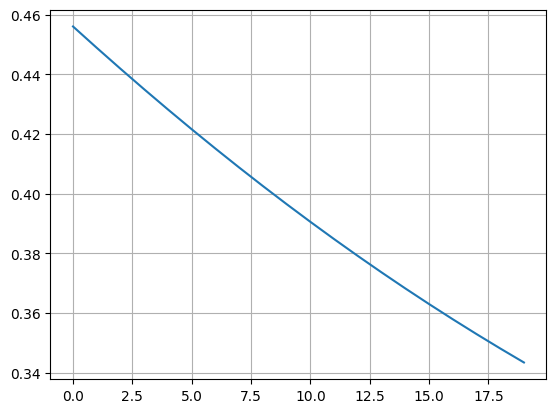

In [51]:
plt.plot(losses)
plt.grid()
plt.show()

In [128]:
surv = model.survival_curve(seqs)

In [131]:
model.integrated_brier_score(surv[:, 0], ts, cs, jnp.ones_like(ts))

Array(0.09166312, dtype=float32)

In [130]:
surv_, ts_, cs_, ms_ = unroll_time(surv, ts, cs, ms, model.horizon)
assert len(ms_is_) == len(ts_)
model.integrated_brier_score(surv_, ts_, cs_, ms_is_)

Array(0.0924031, dtype=float32)

In [122]:
ms_is_.sum()

Array(93., dtype=float32)

In [126]:
jnp.ones_like(ts).sum()

Array(93, dtype=int32)

In [127]:
surv

Array([[[1.        , 0.65273726, 0.4343406 , 0.31507546, 0.24796921,
         0.19624844],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386]],

       [[1.        , 0.8581503 , 0.74219763, 0.6640936 , 0.6125853 ,
         0.56622034],
        [1.        , 0.8320324 , 0.69871646, 0.61096036, 0.5540632 ,
         0.50369126],
        [1.        , 0.8643606 , 0.7527203 , 0.67711806, 0.627063  ,
         0.58183277],
        [1.        , 0.9270313 , 0.862841  , 0.817081  , 0.7856249 ,
         0.756141  ],
        [1.        , 0.6221622 , 0.39527935, 0.27601442, 0.21087176,
         0.16210386]],

       [[1.        , 0.6794405 , 0.46990314, 0.35180593, 0.28371558,
         0.229967